# **Projet Master S2 : Autopsie d’un Prêteur sur Ordinateur**

**Réalisé par :** Tobji Ranim MDS1 GA

**Dataset :** German Credit Data



## **Introduction**

Le secteur bancaire utilise de plus en plus des modèles de Machine Learning pour automatiser l’octroi de crédit.

Cependant, un modèle performant n’est pas nécessairement fiable, juste ou explicable.

Dans ce projet, nous auditons un modèle de type Random Forest chargé d’accepter ✅ ou refuser ❌ des crédits bancaires.

Le but n’est pas seulement de prédire, mais de répondre à 5 grandes questions :

* Les données sont-elles bonnes ?
* Le modèle est-il performant ?
* Le modèle est-il compréhensible ?
* Les décisions sont-elles justes ?
* Peut-on l’utiliser en entreprise ?


Nous utiliserons des outils modernes d’Explainable AI (SHAP, LIME), ainsi que des métriques de fairness.

## **Importation des bibliothèques**

In [1]:
!pip install lime shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

import shap
import lime
import lime.lime_tabular

sns.set_style("whitegrid")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=da349000251332318f70439bc4fdbf3ecdba27d6dbdabbf10e378fc845b8daf0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


## **Chargement Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("german_credit_data.csv")
df.head()

Saving german_credit_data.csv to german_credit_data.csv


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


## **PARTIE 1️⃣ : CHECK-UP DE BASE (EDA + PCA)**

**Sert à quoi cette partie ?**

Avant de construire un modèle, il faut comprendre les données.

**On cherche à savoir :**

* Qui sont les clients ?
* Les données sont-elles propres ?
* Y a-t-il des valeurs manquantes ?
* Les variables sont-elles équilibrées ?
* Y a-t-il des cas atypiques ?

**Remarque :** Si les données sont mauvaises  ➡ le modèle sera mauvais.

### **Exploration Initiale**

In [3]:
# Affiche le nombre de lignes et de colonnes du dataset.
print(df.shape)

# Donne le type de chaque colonne et le nombre de valeurs non nulles.
print(df.info())

# Compte les valeurs manquantes colonne par colonne.
print(df.isnull().sum())

(1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB
None
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


### **Preprocessing**

Transformer les données brutes en données exploitables par un algorithme.

**Remplir valeurs manquantes**

In [4]:
df["Saving accounts"].fillna("unknown", inplace=True)
df["Checking account"].fillna("unknown", inplace=True)

/tmp/ipykernel_13294/1305407817.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Saving accounts"].fillna("unknown", inplace=True)
/tmp/ipykernel_13294/1305407817.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

**Encoder variables catégorielles**

Les modèles de Machine Learning (comme le Random Forest) ne comprennent pas le texte. Ils ne savent travailler qu'avec des nombres.

In [5]:
# transformer les données textuelles (catégorielles) en nombres entiers
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

**Target**

In [6]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

**Train test split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Répartition classes**

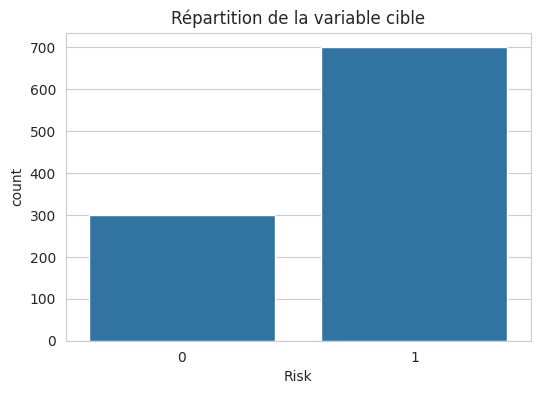

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Répartition de la variable cible")
plt.show()

**Interprétation :**
Le graphique montre un déséquilibre de classe : 70% de bons clients (good) contre 30% de mauvais (bad).

Cependant, ce déséquilibre peut biaiser l’apprentissage : le modèle peut privilégier la majorité.

### **Distribution âge**

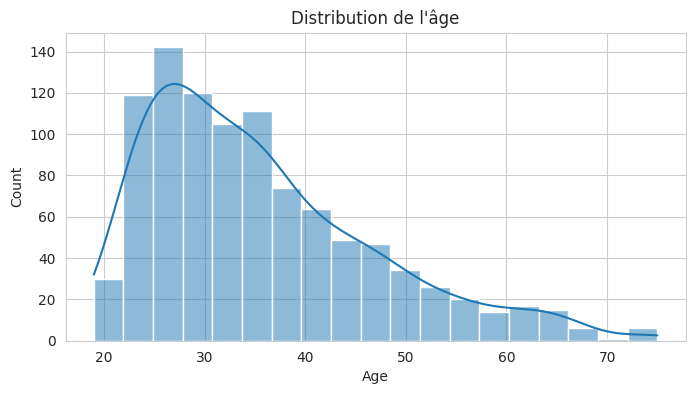

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df["Age"], kde=True)
plt.title("Distribution de l'âge")
plt.show()

**À quoi ça sert le KDE ?**

La courbe lisse l'histogramme pour mieux visualiser la forme globale de la distribution

Permet de voir plus facilement si les données sont : symétriques, asymétriques, bimodales (deux pics)...

**Interprétation :** La distribution est légèrement ***asymétrique*** à droite :
La majorité des clients se situe entre **25 et 40 ans**.

Cela signifie que :

* les jeunes profils ainsi que les seniors sont minoritaires
* la base clients est principalement composée d’adultes

Le modèle risque donc d’être moins précis sur ces catégories sous-représentées.

### **Distribution montant crédit**

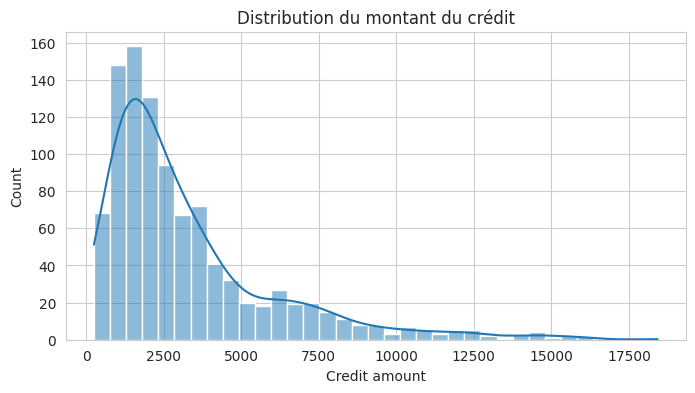

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df["Credit amount"], kde=True)
plt.title("Distribution du montant du crédit")
plt.show()

**Interprétation :**
La distribution est asymétrique : beaucoup de petits crédits (autour de 2000-5000 €) et une longue traîne de gros montants rares (jusqu’à ~18 000 €).

Cela peut influencer le modèle, qui apprend mieux les petits crédits que les gros.

### **Boxplot montant**

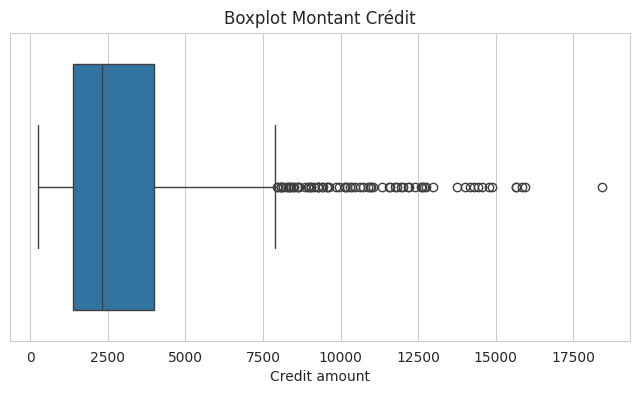

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Credit amount"])
plt.title("Boxplot Montant Crédit")
plt.show()

**Interprétation :**
Confirme la présence de valeurs extrêmes (outliers) au-delà des 10 000 €.

Ces gros crédits pourraient être plus risqués.

### **Heatmap corrélation**

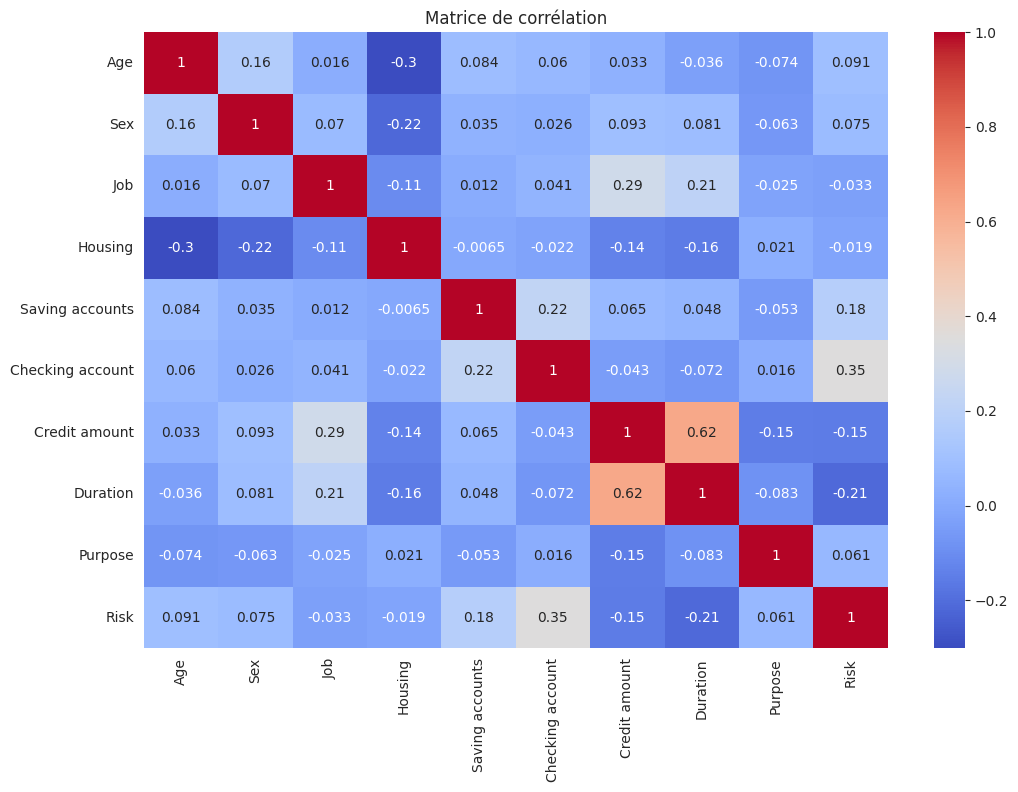

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

**Interprétation :**
On note une corrélation positive notable entre **Credit amount** et **Duration** **→** plus le crédit est gros, plus la durée de remboursement est longue.

Les autres corrélations sont faibles.

### **PCA (Analyse en Composantes Principales)**

**Objectif :** Réduire le nombre de variables tout en conservant un maximum d'information.



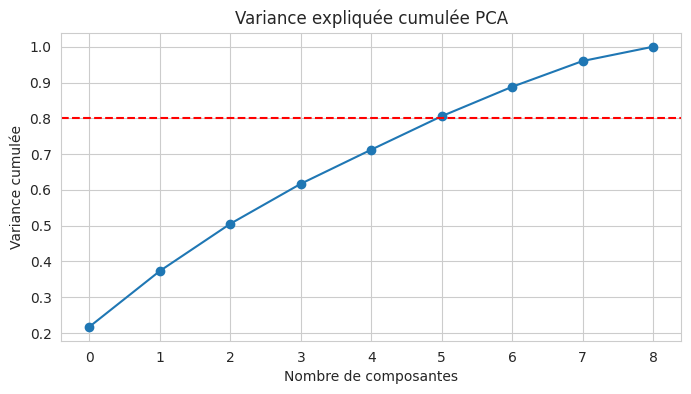

In [13]:
scaler = StandardScaler()       #  Standardise les données (moyenne = 0, écart-type = 1) pour que chaque variable ait le même poids.
X_scaled = scaler.fit_transform(X)

pca = PCA()     # crée de nouvelles variables (composantes principales)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(y=0.80, color="red", linestyle="--")
plt.title("Variance expliquée cumulée PCA")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.show()

Le graphique "variance expliquée cumulée" répond à la question : "**Combien de composantes faut-il pour bien résumer les données ?**"

**Interprétation :**
Le graphique de la variance expliquée cumulée montre qu'il faut environ 5 composantes principales pour expliquer 80 % de la variance totale du jeu de données.

Cela signifie que les données peuvent être résumées efficacement.

### **Biplot**

Le biplot est une visualisation qui combine deux informations sur un même graphique :

**Les individus (les clients)**→ représentés par des points

**Les variables**→ représentées par des flèches

Les flèches indiquent la contribution et la direction des variables.

* **flèches proches** = variables corrélées
* **opposées** = relation inverse
* **longues** = variables importantes

**=> le biplot montre :**

Quelles variables sont les plus importantes ?

Comment les variables sont liées entre elles ?

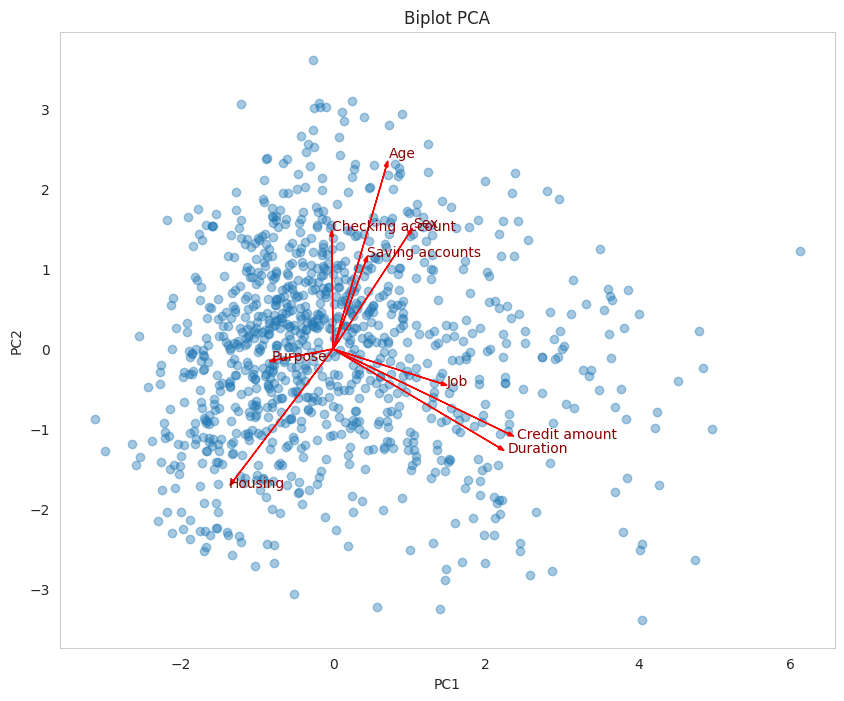

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2 composantes (pour pouvoir les dessiner sur un graphique 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# coordonnées variables
loadings = pca.components_.T

plt.figure(figsize=(10,8))

# points individus
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)

# flèches variables
for i, col in enumerate(X.columns):
    plt.arrow(
        0, 0,
        loadings[i,0]*4,
        loadings[i,1]*4,
        color='red',
        head_width=0.05
    )

    plt.text(
        loadings[i,0]*4.2,
        loadings[i,1]*4.2,
        col,
        color='darkred'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA")
plt.grid()
plt.show()



=> Les flèches montrent que **Credit amount** et **Duration** pointent dans une direction similaire.



## **PARTIE 2️⃣ : DIAGNOSTIC MÉDICAL**

### **Entraînement modèle**

**Sert à quoi ?**

Créer un système qui prédit automatiquement :

- bon client

- client risqué

**Pourquoi RandomForest ?**

Car il est :
- performant
- robuste
- gère données mixtes
- explique importance variables

In [15]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:,1]

### **Classification report**

calculer 4 métriques essentielles pour évaluer la performance du modèle.

In [16]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.56      0.55      0.55        60
           1       0.81      0.81      0.81       140

    accuracy                           0.73       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.73      0.73      0.73       200



Pour la classe **bad** (classe 1) :

- **Precision** :	81% des clients prédits bad le sont réellement
- **Recall** :	81% des vrais bad ont été correctement identifiés
- **F1-score** :	Moyenne harmonique de précision et rappel
- **Support**	: Nombre de vrais bad dans le test (140 clients)

**=>** Performance correcte : 81% pour toutes les métriques. Le modèle détecte bien les mauvais payeurs.

Pour la classe **good** (classe 0) :

- **Precision :**	56% des clients prédits good le sont réellement
- **Recall :**	55% des vrais good ont été correctement identifiés
- **F1-score :**	Moyenne des deux
- **Support :**	Nombre de vrais good dans le test (60 clients)

**=>** Performance faible : 55-56%. Le modèle confond souvent les bons clients avec des mauvais.

**Accurancy :** Taux global de bonnes prédictions ,
73% Globalement acceptable, masque les difficultés sur la classe minoritaire.


### **Matrice confusion**

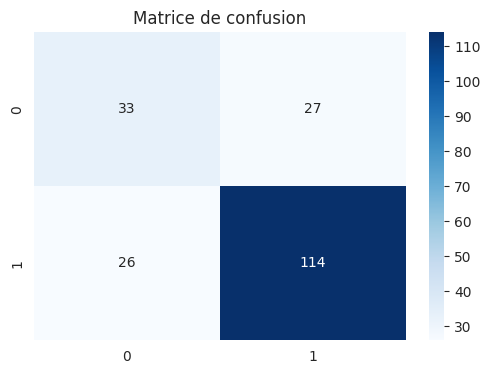

In [17]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.show()


**Interprétation :**

* Vrais Positifs (114) : bons clients bien classés.

* Faux Négatifs (26) : mauvais clients acceptés par erreur → erreur la plus grave (non-remboursement probable).

* Vrais Négatifs (33) : mauvais clients bien rejetés.

* Faux positif (27) : bon client refusé.

### **ROC**

La **ROC** (Receiver Operating Characteristic) est un graphique qui évalue la capacité du modèle à distinguer les bonnes des mauvaises prédictions, quel que soit le seuil choisi.

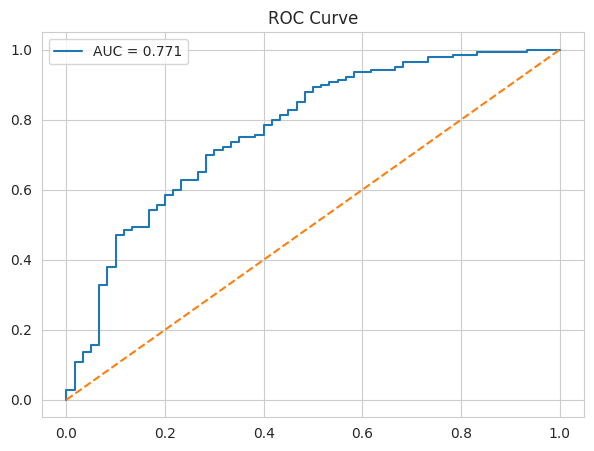

In [18]:
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.legend()
plt.show()

La courbe est au-dessus de la diagonale, le modèle discrimine mieux qu’un hasard.
le modèle a 77% (AUC) de chances de bien classer.

### **Precision Recall**

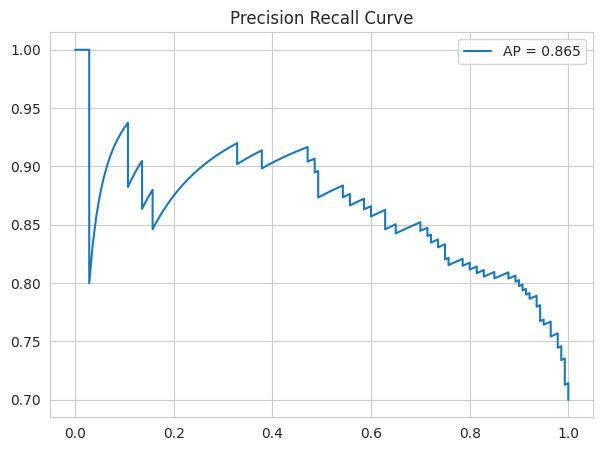

In [19]:
precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.title("Precision Recall Curve")
plt.legend()
plt.show()

**Interprétation :**
AP élevée indique que la précision reste bonne quand on augmente le rappel.

La courbe PR est plus adaptée que ROC car dataset déséquilibré.

**Comparaison :**

La courbe ROC mesure la capacité globale de séparation.
Cependant, sur dataset déséquilibré, elle peut être trop optimiste.

La courbe Precision-Recall est plus pertinente car elle ignore les vrais négatifs et se concentre sur la détection de la classe minoritaire : les clients risqués.

## **PARTIE 3️⃣ : AUTOPSIE GLOBALE**

### **Importance native**

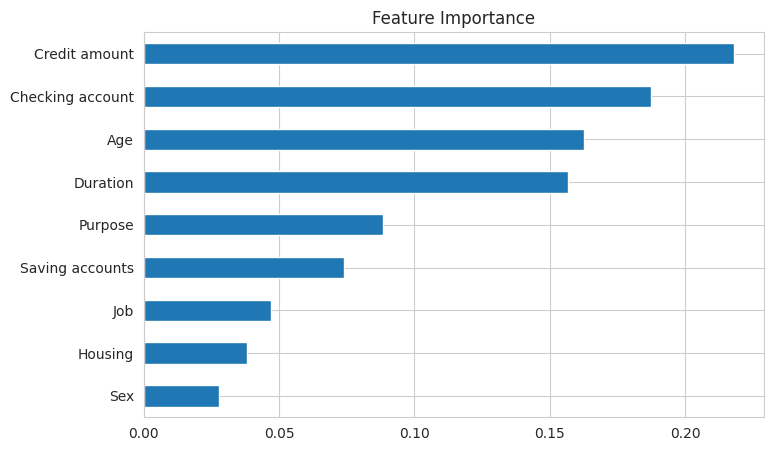

In [21]:
imp = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
imp.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

Les variables les plus importantes sont Credit amount et Duration, suivies des types de comptes bancaires, de l’âge et du job.

### **Permutation importance**

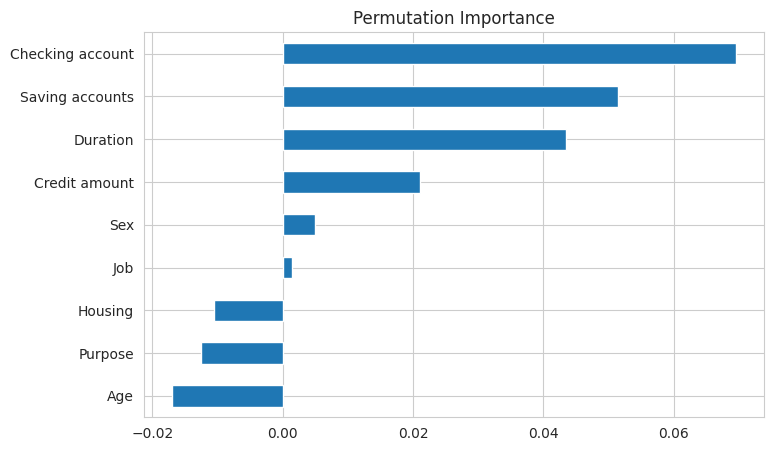

In [22]:
perm = permutation_importance(model, X_test, y_test, n_repeats=10)

perm_imp = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,5))
perm_imp.sort_values().plot(kind="barh")
plt.title("Permutation Importance")
plt.show()


**Interprétation :**
Plus robuste que l’importance native. Confirme que la suppression aléatoire de Credit amount ou Duration dégrade fortement les performances.

=> La permutation importance mesure l'impact réel de chaque variable sur les performances du modèle.

### **SHAP Summary**

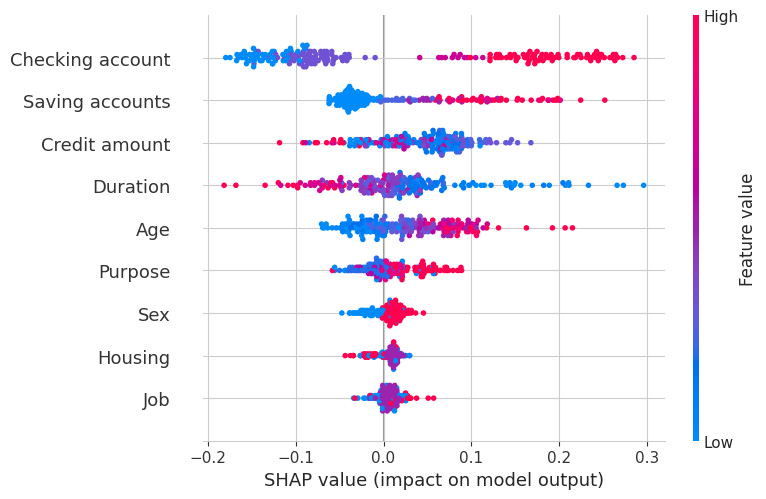

In [23]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values[:,:,1], X_test)

**Interprétation :**

* **Valeurs SHAP élevées (points rouges)** = poussent la prédiction vers bad.

* **Valeurs SHAP faibles (points bleus)** = poussent vers good.

On observe que Credit amount élevé, Duration longue et Checking account faible augmentent fortement le risque de prédiction bad. L’âge élevé est plutôt protecteur.

Variables principales de refus :
*   montant élevé
*   longue durée
*   faible épargne

## **PARTIE 4️⃣ : EXPLICATION CLIENT**

### **Faux négatif / Faux positif**

In [24]:
results = X_test.copy()
results["true"] = y_test.values
results["pred"] = pred

fn = results[(results.true==1)&(results.pred==0)].index[0]
fp = results[(results.true==0)&(results.pred==1)].index[0]

### **LIME**

In [25]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=["No","Yes"],
    mode="classification"
)

exp = explainer_lime.explain_instance(
    X_test.loc[fn].values,
    model.predict_proba
)

exp.show_in_notebook()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### **SHAP Waterfall**

 98%|===================| 393/400 [00:27<00:00]       

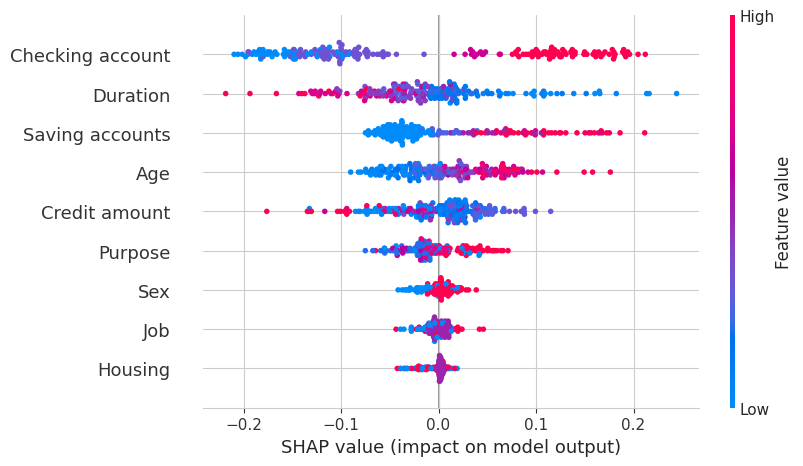

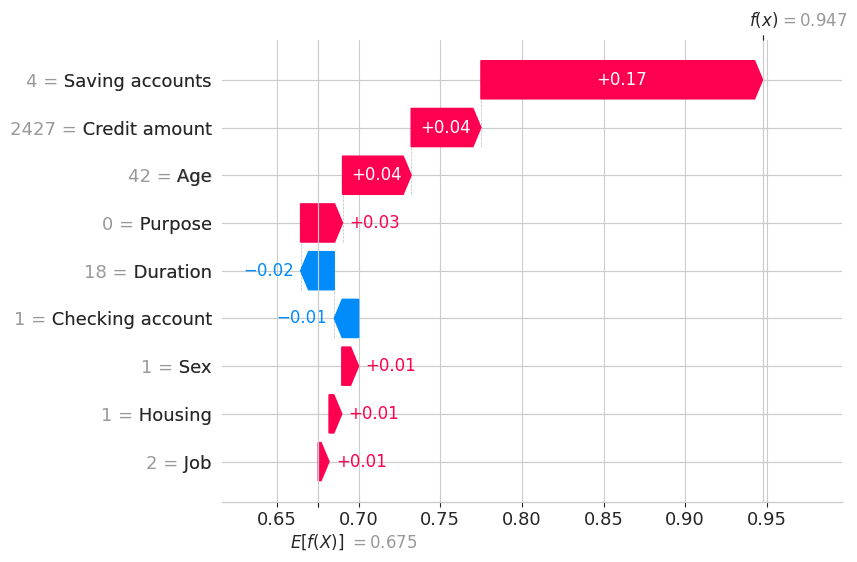

In [29]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values[:,:,1])

shap.plots.waterfall(shap_values[0,:,1])

**Interprétation juridique**

**Faux négatif :**
Le client semblait solvable (montant modéré, épargne correcte) mais risque réel sous-estimé.

**Faux positif :**
Le client avait bon profil réel mais jeune âge + longue durée ont pénalisé score.


Le client est refusé principalement à cause du montant élevé demandé et d’une longue durée de remboursement.
Son âge et ses comptes bancaires réduisent partiellement ce risque.

## **PARTIE 5️⃣ : FAIRNESS + EFFETS MARGINAUX**

### **PDP + ICE**

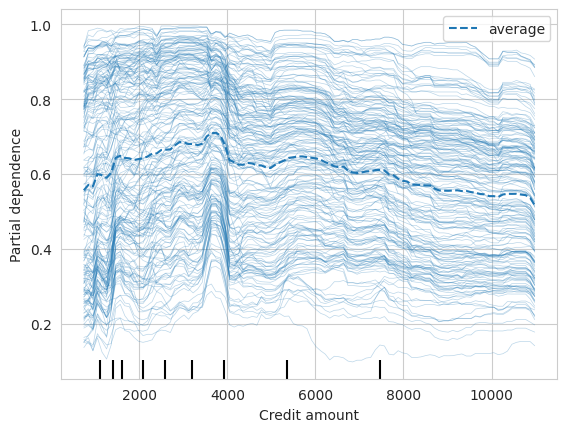

In [27]:
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    ["Credit amount"],
    kind="both"
)

plt.show()

**Interprétation :**

Globalement, plus montant augmente, plus risque augmente.

Mais certains profils supportent mieux un gros prêt.

### **Audit homme/femme**

In [28]:
male = X_test["Sex"] == 1
female = X_test["Sex"] == 0

accept_male = pred[male].mean()
accept_female = pred[female].mean()

print("Taux acceptation hommes :", accept_male)
print("Taux acceptation femmes :", accept_female)

Taux acceptation hommes : 0.7142857142857143
Taux acceptation femmes : 0.6833333333333333


**Interprétation :**

Si écart élevé =>
Risque de discrimination indirecte.

**AI Act**

Le crédit bancaire = système à haut risque.

Nécessite :

supervision humaine
explicabilité
audit biais
documentation

## **CONCLUSION FINALE**

Le modèle Random Forest est performant mais imparfait.

Les décisions reposent surtout sur :
- montant du crédit
- durée du prêt
- situation bancaire
- âge

Des erreurs existent sur profils atypiques.

Le modèle doit assister la décision humaine,
pas remplacer le conseiller bancaire.